In [1]:
pip install selenium pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [2]:
pip install webdriver-manager

In [5]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import numpy as np
import time
import subprocess

# Install Chrome (if not already installed)
try:
    subprocess.run(['google-chrome', '--version'], check=True, capture_output=True)
    print("Google Chrome is already installed.")
except (FileNotFoundError, subprocess.CalledProcessError):
    print("Installing Google Chrome...")
    subprocess.run(['apt-get', 'update'], check=True)
    subprocess.run(['wget', 'https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb'], check=True)
    subprocess.run(['dpkg', '-i', 'google-chrome-stable_current_amd64.deb'], check=False)
    subprocess.run(['apt-get', 'install', '-f', '-y'], check=True)
    print("Google Chrome installed successfully.")

BASE_URL = "https://palestine.io/ar/property-new"

def get_max_page():
    driver.get(BASE_URL)
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "li.page-item a.page-link")))
    links = driver.find_elements(By.CSS_SELECTOR, "li.page-item:not(.next):not(.prev) a.page-link")
    nums = [int(link.text) for link in links if link.text.isdigit()]
    return max(nums) if nums else 1

def get_links_on_page(page):
    driver.get(f"{BASE_URL}?page={page}")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "a.view.btn-pro")))
    return [a.get_attribute("href") for a in driver.find_elements(By.CSS_SELECTOR, "a.view.btn-pro")]

def extract_data(url):
    driver.get(url)
    wait.until(EC.presence_of_element_located((By.ID, "created_at")))

    def get_by_id(id_):
        try:
            return driver.find_element(By.ID, id_).text.strip()
        except:
            return np.nan

    def try_click(trigger):
        try:
            btn = driver.find_element(By.CSS_SELECTOR, f"span.trigger[data-trigger-label='{trigger}']")
            btn.click()
            wait.until(EC.visibility_of_element_located((By.ID, trigger)))
            return driver.find_element(By.ID, trigger).text.strip()
        except:
            return np.nan

    # فصل تاريخ النشر عن الملاحظة
    raw_date_note = get_by_id("created_at")
    if '\n' in raw_date_note:
        date_part, note_part = raw_date_note.split('\n', 1)
    else:
        date_part, note_part = raw_date_note, ""

    services = get_by_id("services")
    services = " / ".join([s.strip() for s in services.split("/") if s.strip()]) if services != "غير متوفر" else services

    return {
        'تاريخ النشر': date_part.strip(),
        'ملاحظة الإعلان': note_part.strip(),
        'العرض': get_by_id("offer"),
        'نوع العقار': get_by_id("property_type"),
        'المساحة': get_by_id("space"),
        'المدينة': get_by_id("city"),
        'المنطقة': get_by_id("location"),
        'تصنيف المنطقة': get_by_id("area_type"),
        'العنوان': get_by_id("address"),
        'تفاصيل': get_by_id("description"),
        'الخدمات والمميزات': services,
        'السعر التقريبي': try_click("rate"),
        'اسم المعلن': get_by_id("name"),
        'هاتف المعلن': try_click("phone")
    }

def main():
    max_page = get_max_page()
    print(f"🔢 عدد الصفحات: {max_page}")

    all_links = []
    for p in range(1, max_page + 1):
        links = get_links_on_page(p)
        print(f"🧷 صفحة {p}: {len(links)} إعلان")
        all_links += links

    print(f"🎯 المجموع: {len(all_links)} إعلان")

    data = []
    for i, link in enumerate(all_links, 1):
        print(f"⏳ {i}/{len(all_links)}", end="\r")
        data.append(extract_data(link))
        time.sleep(0.5)  # تأخير خفيف لحماية السكربت من الحظر أثناء الضغط المتكرر

    df = pd.DataFrame(data)
    df.to_csv("Palestine_real_estate_scraping_output.csv", index=False, encoding="utf-8-sig")
    print("\n✅ تم حفظ الملف: Palestine_real_estate_scraping_output.csv")
    return df

if __name__ == "__main__":
    chrome_options = Options()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--disable-gpu')
    chrome_options.add_argument('--disable-extensions')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--blink-settings=imagesEnabled=false')

    # تعديل طريقة تشغيل الـ Driver هنا ليتوافق تلقائياً مع إصدار المتصفح الحالي
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    wait = WebDriverWait(driver, 7)

    try:
        df = main()
        print(df.head())
    finally:
        driver.quit()

Installing Google Chrome...
Google Chrome installed successfully.
🔢 عدد الصفحات: 44
🧷 صفحة 1: 10 إعلان
🧷 صفحة 2: 10 إعلان
🧷 صفحة 3: 10 إعلان
🧷 صفحة 4: 10 إعلان
🧷 صفحة 5: 10 إعلان
🧷 صفحة 6: 10 إعلان
🧷 صفحة 7: 10 إعلان
🧷 صفحة 8: 10 إعلان
🧷 صفحة 9: 10 إعلان
🧷 صفحة 10: 10 إعلان
🧷 صفحة 11: 10 إعلان
🧷 صفحة 12: 10 إعلان
🧷 صفحة 13: 10 إعلان
🧷 صفحة 14: 10 إعلان
🧷 صفحة 15: 10 إعلان
🧷 صفحة 16: 10 إعلان
🧷 صفحة 17: 10 إعلان
🧷 صفحة 18: 10 إعلان
🧷 صفحة 19: 10 إعلان
🧷 صفحة 20: 10 إعلان
🧷 صفحة 21: 10 إعلان
🧷 صفحة 22: 10 إعلان
🧷 صفحة 23: 10 إعلان
🧷 صفحة 24: 10 إعلان
🧷 صفحة 25: 10 إعلان
🧷 صفحة 26: 10 إعلان
🧷 صفحة 27: 10 إعلان
🧷 صفحة 28: 10 إعلان
🧷 صفحة 29: 10 إعلان
🧷 صفحة 30: 10 إعلان
🧷 صفحة 31: 10 إعلان
🧷 صفحة 32: 10 إعلان
🧷 صفحة 33: 10 إعلان
🧷 صفحة 34: 10 إعلان
🧷 صفحة 35: 10 إعلان
🧷 صفحة 36: 10 إعلان
🧷 صفحة 37: 10 إعلان
🧷 صفحة 38: 10 إعلان
🧷 صفحة 39: 10 إعلان
🧷 صفحة 40: 10 إعلان
🧷 صفحة 41: 10 إعلان
🧷 صفحة 42: 10 إعلان
🧷 صفحة 43: 10 إعلان
🧷 صفحة 44: 1 إعلان
🎯 المجموع: 431 إعلان

✅ تم حفظ الملف: Palestin

In [6]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن
0,30/12/2025,,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978
1,28/04/2026,,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033
2,24/04/2026,,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412
3,18/04/2026,,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635
4,15/04/2026,,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181


In [7]:
from google.colab import files
files.download("Palestine_real_estate_scraping_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import pandas as pd
import re


myData = pd.read_csv("Palestine_real_estate_scraping_output.csv")
myData.head()

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366


In [9]:
myData.shape

(431, 14)

In [10]:
# معلومات عامة
myData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   تاريخ النشر        431 non-null    object
 1   ملاحظة الإعلان     397 non-null    object
 2   العرض              431 non-null    object
 3   نوع العقار         431 non-null    object
 4   المساحة            431 non-null    object
 5   المدينة            431 non-null    object
 6   المنطقة            431 non-null    object
 7   تصنيف المنطقة      340 non-null    object
 8   العنوان            423 non-null    object
 9   تفاصيل             428 non-null    object
 10  الخدمات والمميزات  398 non-null    object
 11  السعر التقريبي     431 non-null    object
 12  اسم المعلن         431 non-null    object
 13  هاتف المعلن        289 non-null    object
dtypes: object(14)
memory usage: 47.3+ KB


In [11]:
# ملخص إحصائي
print(myData.describe(include='all'))

       تاريخ النشر                                     ملاحظة الإعلان  العرض  \
count          431                                                397    431   
unique         263                                                  1      3   
top     27/01/2023  هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...  للبيع   
freq            11                                                397    388   

       نوع العقار       المساحة           المدينة         المنطقة  \
count         431           431               431             431   
unique          9           219                12             100   
top      قطعة ارض  500 متر مربع  رام الله والبيرة  مدينة رام الله   
freq          179            15               155              61   

       تصنيف المنطقة                     العنوان  \
count            340                         423   
unique             3                         386   
top                أ  الطيرة، خلف مدارس المستقبل   
freq             270                         

In [12]:
myData.replace("غير متوفر", pd.NA, inplace=True)

In [13]:
print(myData.isnull().sum())

تاريخ النشر            0
ملاحظة الإعلان        34
العرض                  0
نوع العقار             0
المساحة                0
المدينة                0
المنطقة                0
تصنيف المنطقة         91
العنوان                8
تفاصيل                 3
الخدمات والمميزات     33
السعر التقريبي         0
اسم المعلن             0
هاتف المعلن          142
dtype: int64


In [14]:
myData = myData.drop(columns=["ملاحظة الإعلان", "تفاصيل","اسم المعلن","هاتف المعلن"])
myData.head()

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع


In [15]:
import numpy as np
import re


def clean_text(text):
    tashkeel = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = tashkeel.sub('', text)
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text.lower()

def word_to_number(text):
    text = clean_text(text)
    pattern = re.compile(r'(\d+)\s*(الاف|ألف|آلاف|1000)')
    text = pattern.sub(lambda m: str(int(m.group(1)) * 1000), text)
    text = re.sub(r'(\d+)\s*ملايين?', lambda m: str(int(m.group(1)) * 1_000_000), text)
    text = re.sub(r'\bالف\b', '1000', text)
    text = text.replace("ألف", "1000")
    text = text.replace("الاف", "1000")
    text = text.replace("مليون", "1000000")
    text = text.replace("ملايين", "1000000")
    def merge_numbers(match):
        first_num = int(match.group(1))
        second_num = int(match.group(2))
        if second_num == 1000:
            return str(first_num * 1000)
        else:
            return f"{first_num} {second_num}"
    text = re.sub(r'(\d+)\s+(\d+)', merge_numbers, text)
    return text

def convert_price_to_usd(price_text):
    if pd.isna(price_text):
        return np.nan
    price_text_clean = word_to_number(str(price_text))
    exchange_rates = {
        "شيكل": 0.27,
        "₪": 0.27,
        "دينار": 1.41,
        "jd": 1.41,
        "دولار": 1.0,
        "$": 1.0
    }
    numbers = re.findall(r'\d+', price_text_clean)
    numbers = [int(n) for n in numbers]
    if not numbers:
        return np.nan
    avg_price = sum(numbers[:2]) / min(len(numbers), 2)
    price_text_lower = price_text_clean.lower()
    for currency, rate in exchange_rates.items():
        if re.search(currency, price_text_lower):
            return round(avg_price * rate, 3)
    return round(avg_price, 3)

myData['السعر_بالدولار'] = myData['السعر التقريبي'].apply(convert_price_to_usd)


In [16]:
# اختبار
text = "60 الف الى 70 الف دينار / لكامل العقار"
usd_price = convert_price_to_usd(text)
print(f"السعر بالدولار = {usd_price}")


السعر بالدولار = 91650.0


In [17]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0
...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0


In [18]:
# مثال: ملء القيم الرقمية المتوسطة
myData["السعر_بالدولار"] = pd.to_numeric(myData["السعر_بالدولار"], errors="coerce")
myData["السعر_بالدولار"].fillna(myData["السعر_بالدولار"].median(), inplace=True)

# ملء النصوص بقيمة شائعة
myData["المنطقة"].fillna("غير محدد", inplace=True)

/tmp/ipykernel_3929/101220828.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myData["السعر_بالدولار"].fillna(myData["السعر_بالدولار"].median(), inplace=True)
/tmp/ipykernel_3929/101220828.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [19]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0
...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
myData["location_encoded"] = le.fit_transform(myData["المدينة"])


In [21]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,location_encoded
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,2
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,1
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,5
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,11
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,8
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,5
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,4
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,5


3. توحيد الخصائص الرقمية (Normalization / Standardization)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
myData["price_scaled"] = scaler.fit_transform(myData[["السعر_بالدولار"]])

In [23]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,location_encoded,price_scaled
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,2,-0.779046
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,1,-0.347635
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,5,0.066211
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,11,-0.767479
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,5,0.057643
...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,8,-0.347635
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,5,0.637428
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,4,-0.428177
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,5,-0.250814


 4. معالجة القيم المتطرفة (Outliers)

In [24]:
Q1 = myData["السعر_بالدولار"].quantile(0.25)
Q3 = myData["السعر_بالدولار"].quantile(0.75)
IQR = Q3 - Q1

# تحديد القيم المتطرفة
outliers = myData[(myData["السعر_بالدولار"] < (Q1 - 1.5 * IQR)) | (myData["السعر_بالدولار"] > (Q3 + 1.5 * IQR))]

# إزالة القيم المتطرفة إن لزم الأمر
myData = myData[~myData.index.isin(outliers.index)]


In [25]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,location_encoded,price_scaled
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,2,-0.779046
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,1,-0.347635
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,5,0.066211
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,11,-0.767479
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,5,0.057643
...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,8,-0.347635
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,5,0.637428
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,4,-0.428177
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,5,-0.250814


📝 معلومات عامة:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   تاريخ النشر        431 non-null    object
 1   ملاحظة الإعلان     397 non-null    object
 2   العرض              431 non-null    object
 3   نوع العقار         431 non-null    object
 4   المساحة            431 non-null    object
 5   المدينة            431 non-null    object
 6   المنطقة            431 non-null    object
 7   تصنيف المنطقة      340 non-null    object
 8   العنوان            423 non-null    object
 9   تفاصيل             428 non-null    object
 10  الخدمات والمميزات  398 non-null    object
 11  السعر التقريبي     431 non-null    object
 12  اسم المعلن         431 non-null    object
 13  هاتف المعلن        289 non-null    object
dtypes: object(14)
memory usage: 47.3+ KB
None

🔍 عدد القيم الفارغة:
تاريخ النشر            0
ملاحظة الإعلان        34
العرض   

/tmp/ipykernel_3929/865446254.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(df["price"].median(), inplace=True)
/tmp/ipykernel_3929/865446254.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

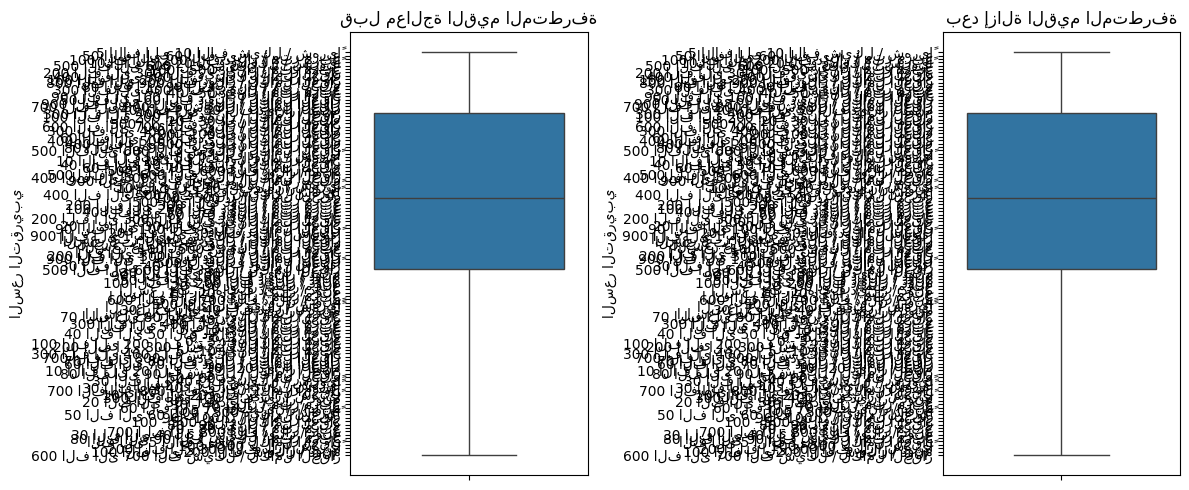

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. قراءة البيانات
df = pd.read_csv("Palestine_real_estate_scraping_output.csv")

# 2. عرض معلومات مبدئية
print("📝 معلومات عامة:")
print(df.info())

print("\n🔍 عدد القيم الفارغة:")
print(df.isnull().sum())

# تحويل العمود price إلى رقم إن لم يكن رقميًا
df["price"] = pd.to_numeric(df["السعر التقريبي"], errors="coerce")

# 3. معالجة القيم الفارغة
# تعبئة price بالوسيط
df["price"].fillna(df["price"].median(), inplace=True)

# تعبئة location والخدمات location/services
df["المنطقة"].fillna("غير محدد", inplace=True)
df["الخدمات والمميزات"].fillna("غير محدد", inplace=True)

# 4. ترميز الأعمدة النصية
label_encoders = {}
for col in ["المنطقة", "الخدمات والمميزات"]:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col])
    label_encoders[col] = le

# 5. توحيد القيم العددية (Standardization)
scaler = StandardScaler()
df["price_scaled"] = scaler.fit_transform(df[["price"]])

# 6. كشف القيم المتطرفة في السعر (IQR method)
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# تحديد القيم المتطرفة
outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"\n📌 عدد القيم المتطرفة المكتشفة: {len(outliers)}")

# إزالة القيم المتطرفة (اختياري)
df_cleaned = df[~df.index.isin(outliers.index)]

# 7. عرض عينة من البيانات المعالجة
print("\n✅ عينة من البيانات بعد المعالجة:")
print(df_cleaned[["price", "price_scaled", "المنطقة", "المنطقة_encoded", "الخدمات والمميزات", "الخدمات والمميزات_encoded"]].head())

# 8. حفظ البيانات النهائية إلى ملف CSV جديد
df_cleaned.to_csv("real_estate_preprocessed.csv", index=False)
print("\n📁 تم حفظ الملف المعالج باسم: real_estate_preprocessed.csv")

# 9. رسم السعر قبل وبعد المعالجة
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(df["السعر التقريبي"])
plt.title("قبل معالجة القيم المتطرفة")

plt.subplot(1, 2, 2)
sns.boxplot(df_cleaned["السعر التقريبي"])
plt.title("بعد إزالة القيم المتطرفة")

plt.tight_layout()
plt.show()

In [27]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,price,المنطقة_encoded,الخدمات والمميزات_encoded,price_scaled
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,NaN,61,143,NaN
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,NaN,88,48,NaN
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,NaN,33,163,NaN
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,NaN,97,184,NaN
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,NaN,92,68,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444,NaN,95,39,NaN
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123,NaN,70,125,NaN
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306,NaN,72,222,NaN
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181,NaN,87,6,NaN


/tmp/ipykernel_3929/866760707.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].fillna(df["price"].median(), inplace=True)
/tmp/ipykernel_3929/866760707.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'


📌 عدد القيم المتطرفة المكتشفة: 57

✅ عينة من البيانات المعالجة:
   price  price_scaled         المنطقة  المنطقة_encoded  \
0    7.5     -0.974954           شعفاط               61   
1  286.0     -0.560932    مدينة الخليل               88   
2  555.0     -0.161033         بيتونيا               33   
3   15.0     -0.963805     مدينة نابلس               97   
4  550.0     -0.168466  مدينة رام الله               92   

                                   الخدمات والمميزات  \
0  ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...   
1  ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...   
2  ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...   
3  ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...   
4  ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...   

   الخدمات والمميزات_encoded  
0                        143  
1                         48  
2                        163  
3                        184  
4                         68  

📁 تم حفظ البيانات المعالجة في: real_estate_preprocessed.

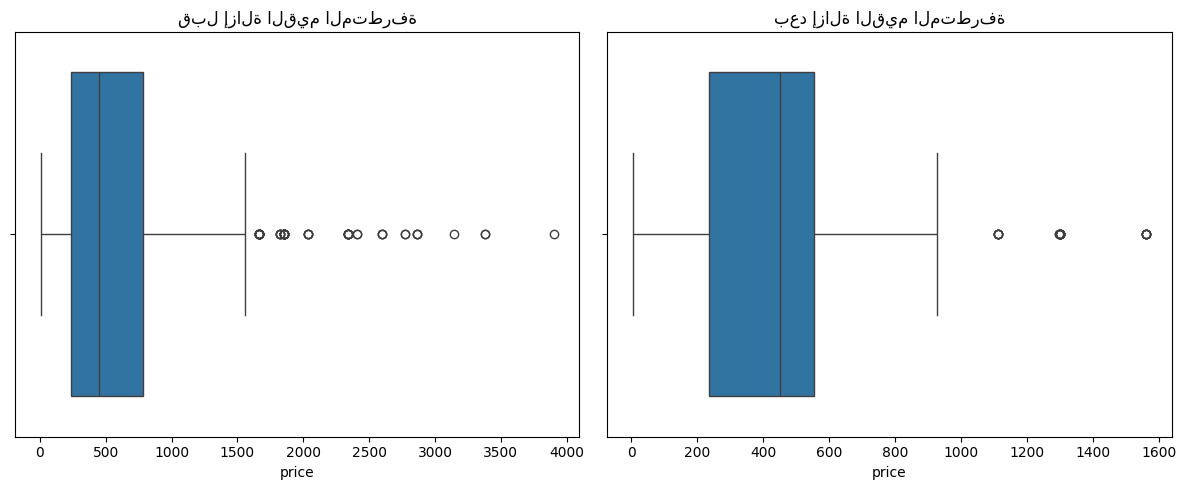

In [28]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. قراءة البيانات
df = pd.read_csv("Palestine_real_estate_scraping_output.csv")

# 2. تعريف دالة استخراج السعر المتوسط
def extract_average_price(text):
    if pd.isna(text):
        return np.nan

    text = text.lower()
    numbers = re.findall(r'\d+', text)
    numbers = list(map(int, numbers))

    if len(numbers) >= 2:
        avg = sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        avg = numbers[0]
    else:
        return np.nan

    # تحويل العملة إن وُجدت
    if "دولار" in text:
        avg *= 3.7  # تحويل تقديري للدولار إلى شيكل
    elif "دينار" in text:
        avg *= 5.2  # تحويل تقديري للدينار إلى شيكل

    return avg

# 3. تطبيق الدالة على عمود السعر النصي
df["price"] = df["السعر التقريبي"].apply(extract_average_price)

# 4. معالجة القيم الفارغة
df["price"].fillna(df["price"].median(), inplace=True)
df["المنطقة"].fillna("غير محدد", inplace=True)
df["الخدمات والمميزات"].fillna("غير محدد", inplace=True)

# 5. ترميز الأعمدة النصية
label_encoders = {}
for col in ["المنطقة", "الخدمات والمميزات"]:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col])
    label_encoders[col] = le

# 6. توحيد القيم الرقمية
scaler = StandardScaler()
df["price_scaled"] = scaler.fit_transform(df[["price"]])

# 7. كشف القيم المتطرفة في السعر (IQR method)
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
print(f"\n📌 عدد القيم المتطرفة المكتشفة: {len(outliers)}")

# 8. إزالة القيم المتطرفة (اختياري)
df_cleaned = df[~df.index.isin(outliers.index)]

# 9. عرض عينة من البيانات بعد المعالجة
print("\n✅ عينة من البيانات المعالجة:")
print(df_cleaned[["price", "price_scaled", "المنطقة", "المنطقة_encoded", "الخدمات والمميزات", "الخدمات والمميزات_encoded"]].head())

# 10. حفظ الملف النهائي
df_cleaned.to_csv("real_estate_preprocessed.csv", index=False)
print("\n📁 تم حفظ البيانات المعالجة في: real_estate_preprocessed.csv")

# 11. رسم السعر قبل وبعد المعالجة
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df["price"])
plt.title("قبل إزالة القيم المتطرفة")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned["price"])
plt.title("بعد إزالة القيم المتطرفة")

plt.tight_layout()
plt.show()


In [30]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,price,المنطقة_encoded,الخدمات والمميزات_encoded,price_scaled
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,7.5,61,143,-0.974954
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,286.0,88,48,-0.560932
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,555.0,33,163,-0.161033
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,15.0,97,184,-0.963805
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,550.0,92,68,-0.168466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444,286.0,95,39,-0.560932
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123,925.0,70,125,0.389015
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306,234.0,72,222,-0.638236
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181,350.0,87,6,-0.465789


# Step 2

In [32]:
column_name = "السعر التقريبي"

def extract_price_range_usd(price_text):
    if pd.isna(price_text):
        return np.nan, np.nan

    price_text_clean = word_to_number(str(price_text))

    exchange_rates = {
        "شيكل": 0.27,
        "₪": 0.27,
        "دينار": 1.41,
        "jd": 1.41,
        "دولار": 1.0,
        "$": 1.0
    }

    numbers_found = re.findall(r'\\d+', price_text_clean)
    numbers_found = [int(n) for n in numbers_found]

    if not numbers_found:
        return np.nan, np.nan

    lower_bound = np.nan
    upper_bound = np.nan

    if len(numbers_found) >= 2:
        lower_bound = numbers_found[0]
        upper_bound = numbers_found[1]
    elif len(numbers_found) == 1:
        lower_bound = numbers_found[0]
        upper_bound = numbers_found[0]

    conversion_rate = 1.0 # Default to dollar if no currency found
    price_text_lower = price_text_clean.lower()
    for currency, rate in exchange_rates.items():
        if re.search(currency, price_text_lower):
            conversion_rate = rate
            break

    if not pd.isna(lower_bound):
        lower_bound_usd = round(lower_bound * conversion_rate, 3)
    else:
        lower_bound_usd = np.nan

    if not pd.isna(upper_bound):
        upper_bound_usd = round(upper_bound * conversion_rate, 3)
    else:
        upper_bound_usd = np.nan

    return lower_bound_usd, upper_bound_usd

# استخراج الحدين الأدنى والأقصى
myData[["السعر_الحد_الادنى", "السعر_الحد_الأقصى"]] = myData[column_name].apply(
    lambda x: pd.Series(extract_price_range_usd(x))
)

# إنشاء عمود المتوسط الحسابي
myData["متوسط_السعر_بالدولار"] = myData[["السعر_الحد_الادنى", "السعر_الحد_الأقصى"]].mean(axis=1)

/tmp/ipykernel_3929/1639109323.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myData[["السعر_الحد_الادنى", "السعر_الحد_الأقصى"]] = myData[column_name].apply(
/tmp/ipykernel_3929/1639109323.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myData[["السعر_الحد_الادنى", "السعر_الحد_الأقصى"]] = myData[column_name].apply(
/tmp/ipykernel_3929/1639109323.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

# 2. Data Preprocessing

تعويض القيم المفقودة

✅ 1. Handle Missing Data – معالجة القيم المفقودة:
✅ عرض عدد القيم المفقودة لكل عمود (isnull().sum()).

✅ تعويض القيم الرقمية المفقودة في السعر_بالدولار بـ المتوسط.

✅ تعويض القيم النصية المفقودة في الخدمات والمميزات بـ "غير محدد".

In [36]:
missing_summary = myData.isnull().sum()
print(missing_summary[missing_summary > 0])

تصنيف المنطقة            78
العنوان                   8
الخدمات والمميزات        25
السعر_الحد_الادنى       389
السعر_الحد_الأقصى       389
متوسط_السعر_بالدولار    389
dtype: int64


In [37]:
# تعويض القيم المفقودة بالمتوسط
myData['السعر_بالدولار'].fillna(myData['السعر_بالدولار'].mean(), inplace=True)


/tmp/ipykernel_3929/301547644.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myData['السعر_بالدولار'].fillna(myData['السعر_بالدولار'].mean(), inplace=True)
/tmp/ipykernel_3929/301547644.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myData['السعر_بالدولار'].fillna(myData['السعر_بالدولار'].mean(), inplace=True)


In [38]:
# تعويض بنص ثابت
myData['الخدمات والمميزات'].fillna("غير محدد", inplace=True)

/tmp/ipykernel_3929/88830587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myData['الخدمات والمميزات'].fillna("غير محدد", inplace=True)
/tmp/ipykernel_3929/88830587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myData['الخدمات والمميزات'].fillna("غير محدد", inplace=True)


In [39]:
print("عدد القيم المفقودة بعد المعالجة:")
print(myData.isnull().sum())


عدد القيم المفقودة بعد المعالجة:
تاريخ النشر               0
العرض                     0
نوع العقار                0
المساحة                   0
المدينة                   0
المنطقة                   0
تصنيف المنطقة            78
العنوان                   8
الخدمات والمميزات         0
السعر التقريبي            0
السعر_بالدولار            0
location_encoded          0
price_scaled              0
السعر_الحد_الادنى       389
السعر_الحد_الأقصى       389
متوسط_السعر_بالدولار    389
dtype: int64


# التعامل مع القيم الشاذة (Outliers)؟



### لاكتشاف وإزالة Outliers من عمود السعر_بالدولار

##### حذف أي عقار سعره خارج المجال المقبول.

يعطيك رسم توضيحي يبين الفرق قبل وبعد المعالجة.

يتم حفظ البيانات المنقحة في myData بعد إزالة الشواذ.

✅ 3. Outlier Treatment – معالجة القيم الشاذة:
✅ استخدام طريقة IQR (Interquartile Range) لاكتشاف القيم الشاذة في عمود السعر_بالدولار.

✅ إزالة الصفوف التي تقع خارج النطاق المقبول (Q1 - 1.5×IQR إلى Q3 + 1.5×IQR).

✅ عرض عدد الصفوف المحذوفة ورسم توضيحي (Boxplot).

عدد العقارات قبل الفلترة: 389
عدد العقارات بعد الفلترة: 389
عدد القيم الشاذة التي تم حذفها: 0


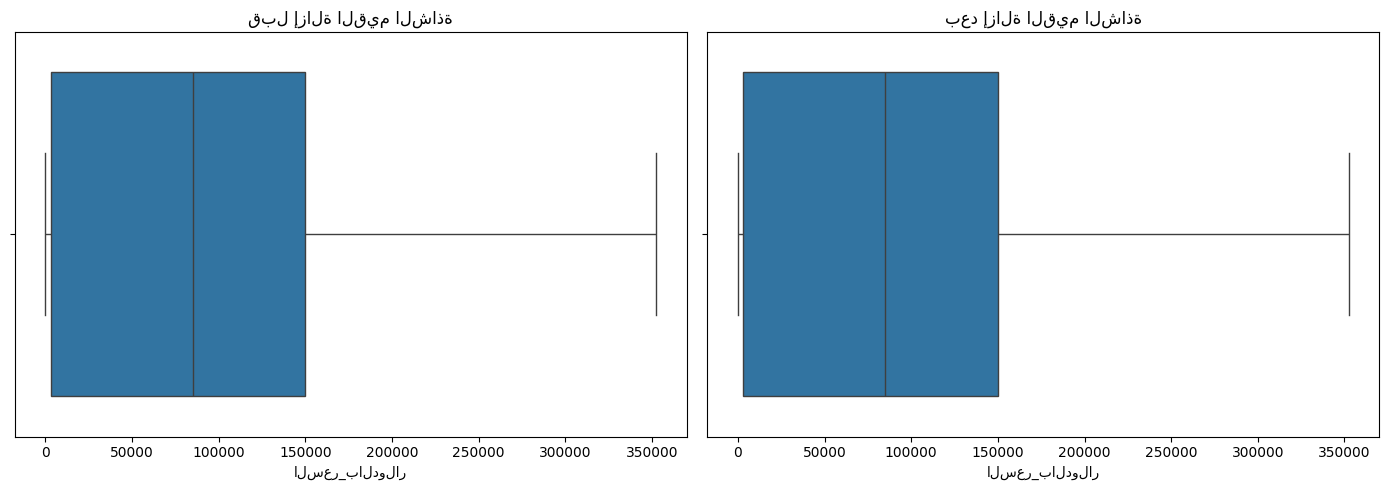

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# حساب IQR
Q1 = myData['السعر_بالدولار'].quantile(0.25)
Q3 = myData['السعر_بالدولار'].quantile(0.75)
IQR = Q3 - Q1

# تحديد الحد الأدنى والأقصى المقبول
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# فلترة البيانات للتخلص من القيم الشاذة
filtered_data = myData[(myData['السعر_بالدولار'] >= lower_bound) & (myData['السعر_بالدولار'] <= upper_bound)]

print(f"عدد العقارات قبل الفلترة: {len(myData)}")
print(f"عدد العقارات بعد الفلترة: {len(filtered_data)}")
print(f"عدد القيم الشاذة التي تم حذفها: {len(myData) - len(filtered_data)}")

# رسم بياني قبل وبعد
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=myData['السعر_بالدولار'])
plt.title("قبل إزالة القيم الشاذة")

plt.subplot(1, 2, 2)
sns.boxplot(x=filtered_data['السعر_بالدولار'])
plt.title("بعد إزالة القيم الشاذة")

plt.tight_layout()
plt.show()

# تحديث البيانات الرئيسية
myData = filtered_data.copy()


# إعادة ضبط القيم العددية (Normalization أو Standardization)؟

✅ 2. Feature Rescaling – إعادة ضبط القيم العددية:
✅ تم استخدام Standardization (Z-score) عبر StandardScaler من scikit-learn على عمود السعر_بالدولار.

✅ حفظ النتيجة في عمود جديد: السعر_بالدولار_مقياسي.

In [42]:
# تطبيق Standardization على عمود السعر_بالدولار

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# تطبيق المقياس على العمود وتحويله إلى عمود جديد
myData['السعر_بالدولار_مقياسي'] = scaler.fit_transform(myData[['السعر_بالدولار']])

# عرض بعض النتائج
print(myData[['السعر_بالدولار', 'السعر_بالدولار_مقياسي']].head())


   السعر_بالدولار  السعر_بالدولار_مقياسي
0          2025.0              -1.038646
1         77550.0              -0.145987
2        150000.0               0.710328
3          4050.0              -1.014712
4        148500.0               0.692599


In [43]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,location_encoded,price_scaled,السعر_الحد_الادنى,السعر_الحد_الأقصى,متوسط_السعر_بالدولار,السعر_بالدولار_مقياسي
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,2,-0.779046,NaN,NaN,NaN,-1.038646
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,1,-0.347635,NaN,NaN,NaN,-0.145987
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,5,0.066211,NaN,NaN,NaN,0.710328
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,11,-0.767479,NaN,NaN,NaN,-1.014712
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,5,0.057643,NaN,NaN,NaN,0.692599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,8,-0.347635,NaN,NaN,NaN,-0.145987
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,5,0.637428,NaN,NaN,NaN,1.892267
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,4,-0.428177,NaN,NaN,NaN,-0.312640
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,5,-0.250814,NaN,NaN,NaN,0.054352


In [44]:
# Normalization

from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
myData['السعر_بالدولار_منظم'] = normalizer.fit_transform(myData[['السعر_بالدولار']])


In [45]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,location_encoded,price_scaled,السعر_الحد_الادنى,السعر_الحد_الأقصى,متوسط_السعر_بالدولار,السعر_بالدولار_مقياسي,السعر_بالدولار_منظم
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,2,-0.779046,NaN,NaN,NaN,-1.038646,0.005738
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,1,-0.347635,NaN,NaN,NaN,-0.145987,0.219994
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,5,0.066211,NaN,NaN,NaN,0.710328,0.425528
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,11,-0.767479,NaN,NaN,NaN,-1.014712,0.011482
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,5,0.057643,NaN,NaN,NaN,0.692599,0.421272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,8,-0.347635,NaN,NaN,NaN,-0.145987,0.219994
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,5,0.637428,NaN,NaN,NaN,1.892267,0.709218
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,4,-0.428177,NaN,NaN,NaN,-0.312640,0.179994
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,5,-0.250814,NaN,NaN,NaN,0.054352,0.268080


✅ 4. Categorical Encoding – ترميز الأعمدة النصية:
✅ نوع العقار: تم ترميزه بـ Label Encoding في عمود جديد نوع_العقار_encoded.

✅ المدينة: تم ترميزها بـ One-Hot Encoding باستخدام pd.get_dummies().

✅ الخدمات والمميزات: تم تفصيله إلى قائمة ثم ترميزها باستخدام MultiLabelBinarizer وإضافة الأعمدة الناتجة.

Label Encoding (لعمود بسيط مثل نوع العقار

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
myData['نوع_العقار_encoded'] = le.fit_transform(myData['نوع العقار'].astype(str))

# عرض النتائج
print(myData[['نوع العقار', 'نوع_العقار_encoded']].drop_duplicates())


    نوع العقار  نوع_العقار_encoded
0          شقة                   2
3         مكتب                   8
5     قطعة ارض                   5
6   عمارة/مبنى                   3
8          محل                   6
13   بيت مستقل                   0
38        فيلا                   4
39        مخزن                   7
51        رووف                   1


In [47]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,location_encoded,price_scaled,السعر_الحد_الادنى,السعر_الحد_الأقصى,متوسط_السعر_بالدولار,السعر_بالدولار_مقياسي,السعر_بالدولار_منظم,نوع_العقار_encoded
0,30/12/2025,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,2,-0.779046,NaN,NaN,NaN,-1.038646,0.005738,2
1,28/04/2026,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,1,-0.347635,NaN,NaN,NaN,-0.145987,0.219994,2
2,24/04/2026,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,5,0.066211,NaN,NaN,NaN,0.710328,0.425528,2
3,18/04/2026,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,11,-0.767479,NaN,NaN,NaN,-1.014712,0.011482,8
4,15/04/2026,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,5,0.057643,NaN,NaN,NaN,0.692599,0.421272,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,8,-0.347635,NaN,NaN,NaN,-0.145987,0.219994,2
427,27/01/2021,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,5,0.637428,NaN,NaN,NaN,1.892267,0.709218,4
428,26/01/2021,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,4,-0.428177,NaN,NaN,NaN,-0.312640,0.179994,5
429,26/01/2021,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,5,-0.250814,NaN,NaN,NaN,0.054352,0.268080,2


In [48]:
# ✅ One-Hot Encoding (لعمود مثل المدينة):
myData = pd.get_dummies(myData, columns=['المدينة'], prefix='مدينة', drop_first=True)


In [49]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,...,مدينة_القدس,مدينة_بيت لحم,مدينة_جنين,مدينة_رام الله والبيرة,مدينة_سلفيت,مدينة_طوباس,مدينة_طولكرم,مدينة_قطاع غزة,مدينة_قلقيلية,مدينة_نابلس
0,30/12/2025,للايجار,شقة,120 متر مربع,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,...,True,False,False,False,False,False,False,False,False,False
1,28/04/2026,للبيع,شقة,160 متر مربع,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,...,False,False,False,False,False,False,False,False,False,False
2,24/04/2026,للبيع,شقة,171 متر مربع,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,...,False,False,False,True,False,False,False,False,False,False
3,18/04/2026,للايجار,مكتب,110 متر مربع,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,...,False,False,False,False,False,False,False,False,False,True
4,15/04/2026,للبيع,شقة,185 متر مربع,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,للبيع,شقة,168 متر مربع,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,77550.0,...,False,False,False,False,False,False,True,False,False,False
427,27/01/2021,للبيع,فيلا,300 متر مربع,عين سينا,ب,شارع رام الله نابلس,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,250000.0,...,False,False,False,True,False,False,False,False,False,False
428,26/01/2021,للبيع,قطعة ارض,4 دونم,قباطية,أ,شارع الجامعه الامريكيه,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,63450.0,...,False,False,True,False,False,False,False,False,False,False
429,26/01/2021,للبيع,شقة,156 متر مربع,مدينة البيرة,أ,اخر شارع الارسال سردا,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,94500.0,...,False,False,False,True,False,False,False,False,False,False


### ترميز خاص لعمود الخدمات والمميزات

In [50]:
# لأنه يحتوي على قائمة من الميزات (مثلاً: "مصعد، كراج، حديقة") — نستخدم Multi-Label Binarizer:
from sklearn.preprocessing import MultiLabelBinarizer

# تأكد من تحويل النص إلى قائمة
myData['الخدمات_list'] = myData['الخدمات والمميزات'].apply(lambda x: str(x).split(',') if pd.notnull(x) else [])

mlb = MultiLabelBinarizer()
features_encoded = pd.DataFrame(mlb.fit_transform(myData['الخدمات_list']), columns=mlb.classes_)

# دمج النتائج مع البيانات الأصلية
myData = pd.concat([myData, features_encoded], axis=1)

# حذف العمود النصي الأصلي إن رغبت
# myData.drop(columns=['الخدمات والمميزات', 'الخدمات_list'], inplace=True)



In [51]:
myData

,تاريخ النشر,العرض,نوع العقار,المساحة,المنطقة,تصنيف المنطقة,العنوان,الخدمات والمميزات,السعر التقريبي,السعر_بالدولار,...,ماء / كهرباء / موقف للسيارة,ماء / كهرباء / موقف للسيارة / أشجار مثمرة / حديقة / بستان,ماء / كهرباء / موقف للسيارة / حديقة / بستان / عظم,ماء / كهرباء / موقف للسيارة / سور / غير مفروشة,مصعد / إمكانية التقسيط / بلكونة / غير مفروشة,مصعد / موقف للسيارة / إمكانية التقسيط / عظم,مصعد / موقف للسيارة / سدة (عليّة),مصعد / موقف للسيارة / غير مفروشة,موقف للسيارة / إمكانية التقسيط,موقف للسيارة / حديقة / بستان / مفروشة
0,30/12/2025,للايجار,شقة,120 متر مربع,شعفاط,أ,شعفاط,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,2025.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,28/04/2026,للبيع,شقة,160 متر مربع,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,77550.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,24/04/2026,للبيع,شقة,171 متر مربع,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,150000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,18/04/2026,للايجار,مكتب,110 متر مربع,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,4050.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,15/04/2026,للبيع,شقة,185 متر مربع,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,148500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. Model Training & Comparison

مشكلة انحدار Regression
تدريب 3 نماذج انحدار للتنبؤ بسعر العقار بالدولار، ومقارنتها باستخدام:

MSE (متوسط مربع الخطأ)

MAE (متوسط الخطأ المطلق)

R² Score (معامل التحديد)

In [55]:
from sklearn.model_selection import train_test_split

# Create a copy to avoid SettingWithCopyWarning
processed_myData = myData.copy()

# Drop redundant, string, or highly missing columns that are not suitable for direct use as features
columns_to_drop = [
    'تاريخ النشر',
    'المساحة', # Contains 'متر مربع' string
    'العنوان', # Free text, high cardinality
    'السعر التقريبي', # Original string price, 'السعر_بالدولار' is the target
    'الخدمات والمميزات', # Original string, encoded features are separate
    'الخدمات_list', # Intermediate list column for MultiLabelBinarizer
    'نوع العقار', # Original string, 'نوع_العقار_encoded' exists
    'المدينة', # Original string, one-hot encoded columns 'مدينة_...' exist
    'السعر_الحد_الادنى', # Contains many NaNs
    'السعر_الحد_الأقصى', # Contains many NaNs
    'متوسط_السعر_بالدولار', # Contains many NaNs
    'السعر_بالدولار_مقياسي', # Scaled version of the target
    'السعر_بالدولار_منظم', # Normalized version of the target
    'price_scaled' # Another scaled version of the target, from cell zs9r52LeOlUf which was replaced by 1LDC3vz-Psk3
]

# Filter out columns that might not exist after previous processing steps (e.g., if a column was already dropped)
columns_to_drop_existing = [col for col in columns_to_drop if col in processed_myData.columns]
processed_myData = processed_myData.drop(columns=columns_to_drop_existing)

# Handle remaining categorical columns with One-Hot Encoding
# 'العرض', 'المنطقة', 'تصنيف المنطقة' are still categorical strings
processed_myData = pd.get_dummies(processed_myData, columns=['العرض', 'المنطقة', 'تصنيف المنطقة'], drop_first=True)

# Ensure all columns are numeric, fill any remaining NaNs in features with 0 (or median/mean as appropriate for the column)
# A common practice is to fill NaNs for numeric features before training
# For simplicity, filling with 0, but a more sophisticated strategy might be needed for specific columns.
for col in processed_myData.columns:
    if processed_myData[col].dtype == 'object':
        # If any object columns remain, try to convert them or drop them
        # This should ideally not happen if all categoricals are handled
        print(f"Warning: Non-numeric column '{col}' remaining. Dropping for now.")
        processed_myData = processed_myData.drop(columns=[col])
    else:
        processed_myData[col] = processed_myData[col].fillna(processed_myData[col].median() if processed_myData[col].dtype != 'bool' else False)

# Define features and target
# The target 'السعر_بالدولار' was not dropped, so it's still in `processed_myData`
features = processed_myData.drop(columns=['السعر_بالدولار'])
target = processed_myData['السعر_بالدولار']

# Align columns after get_dummies might have different columns in train/test if categories differ
# (though not strictly necessary for the split itself, good for robust feature sets)
# The simplest is to ensure the processed_myData used for features is clean

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print("X_train info after preprocessing:")
X_train.info()

X_train info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 344 entries, 80 to 122
Columns: 363 entries, location_encoded to تصنيف المنطقة_ج
dtypes: bool(103), float64(260)
memory usage: 736.0 KB


### Random Forest Regressor



In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Support Vector Regression
svr = SVR()
svr.fit(X_train, y_train)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [57]:
# عرض أنواع البيانات
print(myData.dtypes[myData.dtypes == "object"])


تاريخ النشر               object
العرض                     object
نوع العقار                object
المساحة                   object
المنطقة                   object
تصنيف المنطقة             object
العنوان                   object
الخدمات والمميزات         object
السعر التقريبي            object
مدينة_الخليل              object
مدينة_القدس               object
مدينة_بيت لحم             object
مدينة_جنين                object
مدينة_رام الله والبيرة    object
مدينة_سلفيت               object
مدينة_طوباس               object
مدينة_طولكرم              object
مدينة_قطاع غزة            object
مدينة_قلقيلية             object
مدينة_نابلس               object
الخدمات_list              object
dtype: object


In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from datetime import datetime

# 1️⃣ تحويل التاريخ إلى عدد الأيام منذ النشر
def convert_date_to_days(date_str):
    try:
        post_date = pd.to_datetime(date_str, dayfirst=True, errors='coerce')
        if pd.isnull(post_date):
            return np.nan
        return (datetime.today() - post_date).days
    except:
        return np.nan

myData['ايام_من_النشر'] = myData['تاريخ النشر'].apply(convert_date_to_days)

# 2️⃣ تحويل المساحة إلى رقم
def extract_area(text):
    try:
        return float(str(text).split()[0].replace(',', '').replace('متر', '').strip())
    except:
        return np.nan

myData['المساحة_رقم'] = myData['المساحة'].apply(extract_area)

# 3️⃣ Label Encoding للأعمدة الفئوية البسيطة
label_cols = ['العرض', 'نوع العقار', 'تصنيف المنطقة', 'المنطقة']
le = LabelEncoder()
for col in label_cols:
    # Ensure column exists and handle potential NaNs before encoding
    if col in myData.columns:
        myData[col + '_encoded'] = le.fit_transform(myData[col].astype(str).fillna('غير محدد'))

# Re-create 'الخدمات_list' to ensure it's clean and contains lists
# This step is critical as 'الخدمات_list' might have become corrupted with NaNs (floats) due to previous operations
myData['الخدمات_list'] = myData['الخدمات والمميزات'].astype(str).apply(lambda x: [s.strip() for s in x.split(',') if s.strip() and s.strip() != 'nan'])

# 4️⃣ ترميز الخدمات باستخدام MultiLabelBinarizer
mlb = MultiLabelBinarizer()
# Ensure all values in 'الخدمات_list' are lists before fitting
services_encoded = pd.DataFrame(mlb.fit_transform(myData['الخدمات_list']), columns=mlb.classes_, index=myData.index)
# Concatenate with original myData, ensuring index alignment
myData = pd.concat([myData, services_encoded], axis=1)

# 5️⃣ التأكد أن الأعمدة مثل مدينة_XXX هي أرقام 0/1
city_cols = [col for col in myData.columns if col.startswith('مدينة_')]
for col in city_cols:
    if col in myData.columns: # Check if column exists
        # Convert boolean dtypes (from get_dummies) to int (0/1)
        if myData[col].dtype == 'bool':
            myData[col] = myData[col].astype(int)
        # Fill any potential NaNs after concat in numeric columns
        myData[col].fillna(0, inplace=True)

# 6️⃣ حذف الأعمدة النصية الأصلية التي لم تعد ضرورية
columns_to_drop_final = [
    'تاريخ النشر', 'العنوان', 'الخدمات والمميزات', 'الخدمات_list', 'المساحة'
] + label_cols

# Filter out columns that might not exist to prevent errors
columns_to_drop_final = [col for col in columns_to_drop_final if col in myData.columns]
myData.drop(columns=columns_to_drop_final, inplace=True)

/tmp/ipykernel_3929/758592091.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myData[col].fillna(0, inplace=True)


In [60]:
import pandas as pd
import re


df = pd.read_csv("Palestine_real_estate_scraping_output.csv")
df.head(20)

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366
5,07/04/2026,NaN,للبيع,قطعة ارض,566 متر مربع,نابلس,صرة,أ,نابلس صره,قطعه ارض مميزه في منطقه صره منطقه فلل ترخيص بن...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,100 - 500 دينار / متر مربع,Fathy Odah,NaN
6,16/03/2026,NaN,للبيع,عمارة/مبنى,1100 متر مربع,الخليل,بيت اولا,NaN,الخليل- بيت اولا- حواره,عمارة سكنية للبيع 3 طوابق وروف بالاضافة في نفس...,ماء / كهرباء / انترنت / شارع رئيسي / شارع فرعي...,200 الف الى 300 الف دينار / لكامل العقار,محمود اليازوري,0568185839
7,31/01/2026,NaN,للبيع,شقة,153 متر مربع,بيت لحم,بيت جالا,أ,بيت جالا - حارة الجورية,شقة للبيع – بيت جالا / شارع فلسطين شقة الطابق ...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,400 الف الى 500 الف شيكل / متر مربع,Issam Maali,0597653656
8,04/01/2026,NaN,للبيع,محل,45 متر مربع,رام الله والبيرة,مدينة البيرة,أ,محل تجاري للبيع بالخلو,محل تجاري للبيع بالخلو محل تجاري في موقع متميز...,ماء / كهرباء / انترنت / شارع رئيسي / موقف للسي...,100 الف الى 200 الف دولار / لكامل العقار,ابو ليث,0598931495
9,01/01/2026,NaN,للبيع,بيت مستقل,140 متر مربع,بيت لحم,بيت جالا,NaN,بيت جالا / الجداول,بيت مستقل بناء عربي قديم مقام على أرض مسحتها ح...,ماء / كهرباء / طابو / شارع فرعي / موقف للسيارة...,800 الف الى 900 الف دولار / لكامل العقار,دانا عساتنه,NaN


التعامل مع القيم الفارغة
### 1_ Handle missing data – معالجة القيم المفقودة

عدد القيم الفارغة في كل عمود

تعبئة الأعمدة النصية مثل "المنطقة", "الخدمات والمميزات"

In [61]:
print(df.isnull().sum())

df["المنطقة"].fillna("غير محدد", inplace=True)
df["الخدمات والمميزات"].fillna("غير محدد", inplace=True)


تاريخ النشر            0
ملاحظة الإعلان        34
العرض                  0
نوع العقار             0
المساحة                0
المدينة                0
المنطقة                0
تصنيف المنطقة         91
العنوان                8
تفاصيل                 3
الخدمات والمميزات     33
السعر التقريبي         0
اسم المعلن             0
هاتف المعلن          142
dtype: int64


/tmp/ipykernel_3929/3808164313.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["المنطقة"].fillna("غير محدد", inplace=True)
/tmp/ipykernel_3929/3808164313.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [62]:
import numpy as np
import re


def clean_text(text):
    tashkeel = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = tashkeel.sub('', text)
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text.lower()

def word_to_number(text):
    text = clean_text(text)
    pattern = re.compile(r'(\d+)\s*(الاف|ألف|آلاف|1000)')
    text = pattern.sub(lambda m: str(int(m.group(1)) * 1000), text)
    text = re.sub(r'(\d+)\s*ملايين?', lambda m: str(int(m.group(1)) * 1_000_000), text)
    text = re.sub(r'\bالف\b', '1000', text)
    text = text.replace("ألف", "1000")
    text = text.replace("الاف", "1000")
    text = text.replace("مليون", "1000000")
    text = text.replace("ملايين", "1000000")
    def merge_numbers(match):
        first_num = int(match.group(1))
        second_num = int(match.group(2))
        if second_num == 1000:
            return str(first_num * 1000)
        else:
            return f"{first_num} {second_num}"
    text = re.sub(r'(\d+)\s+(\d+)', merge_numbers, text)
    return text

def convert_price_to_usd(price_text):
    if pd.isna(price_text):
        return np.nan
    price_text_clean = word_to_number(str(price_text))
    exchange_rates = {
        "شيكل": 0.27,
        "₪": 0.27,
        "دينار": 1.41,
        "jd": 1.41,
        "دولار": 1.0,
        "$": 1.0
    }
    numbers = re.findall(r'\d+', price_text_clean)
    numbers = [int(n) for n in numbers]
    if not numbers:
        return np.nan
    avg_price = sum(numbers[:2]) / min(len(numbers), 2)
    price_text_lower = price_text_clean.lower()
    for currency, rate in exchange_rates.items():
        if re.search(currency, price_text_lower):
            return round(avg_price * rate, 3)
    return round(avg_price, 3)

df['السعر بالدولار'] = df['السعر التقريبي'].apply(convert_price_to_usd)


In [63]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,السعر بالدولار
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,2025.0
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,77550.0
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,150000.0
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,4050.0
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,148500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444,77550.0
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123,250000.0
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306,63450.0
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181,94500.0


ترميز الأعمدة النصية (Label Encoding)

### 4_ Categorical Encoding – ترميز المتغيرات النوعية

In [64]:
from sklearn.preprocessing import LabelEncoder

le_location = LabelEncoder()
le_services = LabelEncoder()

df["region_encoded"] = le_location.fit_transform(df["المنطقة"])
df["services_encoded"] = le_services.fit_transform(df["الخدمات والمميزات"])


In [65]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,السعر بالدولار,region_encoded,services_encoded
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,2025.0,61,143
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,77550.0,88,48
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,150000.0,33,163
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,4050.0,97,184
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,148500.0,92,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444,77550.0,95,39
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123,250000.0,70,125
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306,63450.0,72,222
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181,94500.0,87,6


 توحيد القيم العددية (Standardization)

 ### 2_ Feature Rescaling – توحيد القيم الرقمية

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["price_scaled"] = scaler.fit_transform(df[["السعر بالدولار"]])

In [67]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,السعر بالدولار,region_encoded,services_encoded,price_scaled
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,2025.0,61,143,-0.774804
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,77550.0,88,48,-0.367167
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,150000.0,33,163,0.023874
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,4050.0,97,184,-0.763875
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,148500.0,92,68,0.015778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444,77550.0,95,39,-0.367167
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123,250000.0,70,125,0.563612
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306,63450.0,72,222,-0.443270
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181,94500.0,87,6,-0.275681


كشف القيم المتطرفة وإزالتها (اختياري)

### 3_ Outlier Treatment – معالجة القيم المتطرفة

In [68]:
Q1 = df["السعر بالدولار"].quantile(0.25)
Q3 = df["السعر بالدولار"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# إزالة القيم المتطرفة
df = df[(df["السعر بالدولار"] >= lower_bound) & (df["السعر بالدولار"] <= upper_bound)]


In [69]:
df

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,السعر بالدولار,region_encoded,services_encoded,price_scaled
0,30/12/2025,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,2025.0,61,143,-0.774804
1,28/04/2026,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,77550.0,88,48,-0.367167
2,24/04/2026,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,150000.0,33,163,0.023874
3,18/04/2026,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,4050.0,97,184,-0.763875
4,15/04/2026,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,148500.0,92,68,0.015778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,168 متر مربع,طولكرم,مدينة طولكرم,أ,طولكرم خلف مجمع المحاكم الجديد,طولكرم مجمع المحاكم الجديد شارع الديشه,طابو / مصعد / إمكانية التقسيط / عظم,50 الف الى 60 الف دينار / لكامل العقار,ليندا سودي,0569150444,77550.0,95,39,-0.367167
427,27/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,فيلا,300 متر مربع,رام الله والبيرة,عين سينا,ب,شارع رام الله نابلس,هل تبحث عن فيلا في محافظة رام الله والبيرة؟ لل...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,200 الف الى 300 الف دولار / لكامل العقار,Lafi amleh,0594321123,250000.0,70,125,0.563612
428,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,قطعة ارض,4 دونم,جنين,قباطية,أ,شارع الجامعه الامريكيه,هل تبحث عن قطعة ارض في محافظة جنين؟ للبيع قطعة...,ماء / كهرباء / طابو / شارع رئيسي / شارع فرعي /...,40 الف الى 50 الف دينار / دونم,mohammad kmail,0597209306,63450.0,72,222,-0.443270
429,26/01/2021,هذا الاعلان قديم وليس فعال وتم أرشفته، يمكنك ا...,للبيع,شقة,156 متر مربع,رام الله والبيرة,مدينة البيرة,أ,اخر شارع الارسال سردا,للبيع شقة ١٥٦ متر مربع في مدينة رام الله اخر ش...,تكييف / طابو / شارع رئيسي / مصعد / موقف للسيار...,300 الف الى 400 الف شيكل / لكامل العقار,محمد عبد الحفيظ,0597651181,94500.0,87,6,-0.275681


In [70]:
print("✅ عدد الصفوف بعد إزالة القيم المتطرفة:", len(df))


✅ عدد الصفوف بعد إزالة القيم المتطرفة: 358


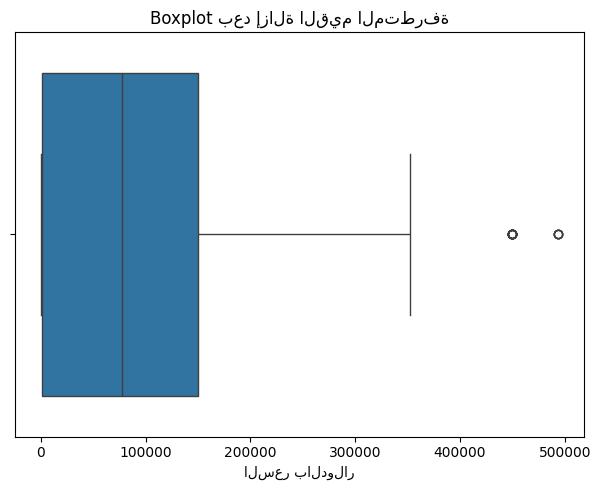

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# قبل الإزالة
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x="السعر بالدولار", data=df)
plt.title("Boxplot بعد إزالة القيم المتطرفة")

plt.tight_layout()
plt.show()


تحويل عمود "تاريخ النشر" إلى datetime

In [72]:
df["تاريخ النشر"] = pd.to_datetime(df["تاريخ النشر"], dayfirst=True, errors='coerce')
df.head(20)

/tmp/ipykernel_3929/246940174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["تاريخ النشر"] = pd.to_datetime(df["تاريخ النشر"], dayfirst=True, errors='coerce')


,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,السعر بالدولار,region_encoded,services_encoded,price_scaled
0,2025-12-30,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,2025.00,61,143,-0.774804
1,2026-04-28,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,77550.00,88,48,-0.367167
2,2026-04-24,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,150000.00,33,163,0.023874
3,2026-04-18,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,4050.00,97,184,-0.763875
4,2026-04-15,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,148500.00,92,68,0.015778
5,2026-04-07,NaN,للبيع,قطعة ارض,566 متر مربع,نابلس,صرة,أ,نابلس صره,قطعه ارض مميزه في منطقه صره منطقه فلل ترخيص بن...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,100 - 500 دينار / متر مربع,Fathy Odah,NaN,423.00,62,116,-0.783451
6,2026-03-16,NaN,للبيع,عمارة/مبنى,1100 متر مربع,الخليل,بيت اولا,NaN,الخليل- بيت اولا- حواره,عمارة سكنية للبيع 3 طوابق وروف بالاضافة في نفس...,ماء / كهرباء / انترنت / شارع رئيسي / شارع فرعي...,200 الف الى 300 الف دينار / لكامل العقار,محمود اليازوري,0568185839,352500.00,23,104,1.116844
7,2026-01-31,NaN,للبيع,شقة,153 متر مربع,بيت لحم,بيت جالا,أ,بيت جالا - حارة الجورية,شقة للبيع – بيت جالا / شارع فلسطين شقة الطابق ...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,400 الف الى 500 الف شيكل / متر مربع,Issam Maali,0597653656,121500.00,24,120,-0.129952
8,2026-01-04,NaN,للبيع,محل,45 متر مربع,رام الله والبيرة,مدينة البيرة,أ,محل تجاري للبيع بالخلو,محل تجاري للبيع بالخلو محل تجاري في موقع متميز...,ماء / كهرباء / انترنت / شارع رئيسي / موقف للسي...,100 الف الى 200 الف دولار / لكامل العقار,ابو ليث,0598931495,150000.00,87,107,0.023874
10,2025-12-15,NaN,للبيع,قطعة ارض,560 متر مربع,نابلس,مدينة نابلس,أ,نابلس الجديدة,للبيع: أرض مميزة في نابلس الجديدة – نابلس المس...,غير محدد,80 الف الى 90 الف دينار / متر مربع,AMJAD JABR,NaN,119850.00,97,43,-0.138857


In [73]:
# تعريف دالة تنظيف النوع
def clean_property_type(text):
    if pd.isna(text):
        return "غير محدد"

    text = text.strip().lower()

    if "شقة" in text or "شقه" in text:
        return "شقة"
    elif "رووف" in text:
        return "رووف"
    elif "فيلا" in text:
        return "فيلا"
    elif "ارض" in text or "أرض" in text:
        return "أرض"
    elif "بيت" in text and "مستقل" in text:
        return "بيت مستقل"
    elif "عمارة" in text:
        return "عمارة"
    else:
        return text

# تطبيق التوحيد
df["نوع العقار الموحد"] = df["نوع العقار"].apply(clean_property_type)

# التحقق من القيم الجديدة
print("✅ القيم الموحدة في عمود النوع:")
print(df["نوع العقار الموحد"].value_counts())


✅ القيم الموحدة في عمود النوع:
نوع العقار الموحد
أرض          145
شقة          115
بيت مستقل     28
محل           22
مكتب          22
فيلا          13
رووف           7
مخزن           4
عمارة          2
Name: count, dtype: int64


/tmp/ipykernel_3929/1404616277.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["نوع العقار الموحد"] = df["نوع العقار"].apply(clean_property_type)


# توحيد المساحة

In [74]:
import numpy as np
import re

def extract_area_in_m2(area_text):
    if pd.isna(area_text):
        return np.nan

    text = area_text.lower()
    text = text.replace("متر مربع", "م")
    text = text.replace("متر", "م")
    text = text.replace("م²", "م")
    text = text.replace("م.", "م")
    text = text.replace("م ", "م")
    text = text.replace("مت", "م")  # تصحيحات محتملة

    # التعامل مع دونم
    if "دونم" in text:
        match = re.search(r'([\d.,]+)', text)
        if match:
            value = match.group(1).replace(',', '.')
            return float(value) * 1000  # دونم = 1000 متر مربع
        else:
            return np.nan

    # التعامل مع متر
    elif "م" in text:
        match = re.search(r'([\d.,]+)', text)
        if match:
            value = match.group(1).replace(',', '.')
            return float(value)
        else:
            return np.nan

    # إذا لم تُذكر الوحدة
    else:
        match = re.search(r'([\d.,]+)', text)
        if match:
            value = match.group(1).replace(',', '.')
            return float(value)
        else:
            return np.nan

# تطبيق على العمود
df["المساحة_متر2"] = df["المساحة"].apply(extract_area_in_m2)

# عرض النتائج
print(df[["المساحة", "المساحة_متر2"]].drop_duplicates().head(10))


          المساحة  المساحة_متر2
0    120 متر مربع         120.0
1    160 متر مربع         160.0
2    171 متر مربع         171.0
3    110 متر مربع         110.0
4    185 متر مربع         185.0
5    566 متر مربع         566.0
6   1100 متر مربع        1100.0
7    153 متر مربع         153.0
8     45 متر مربع          45.0
10   560 متر مربع         560.0


/tmp/ipykernel_3929/3984860314.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["المساحة_متر2"] = df["المساحة"].apply(extract_area_in_m2)


In [75]:
df.head(20)

,تاريخ النشر,ملاحظة الإعلان,العرض,نوع العقار,المساحة,المدينة,المنطقة,تصنيف المنطقة,العنوان,تفاصيل,الخدمات والمميزات,السعر التقريبي,اسم المعلن,هاتف المعلن,السعر بالدولار,region_encoded,services_encoded,price_scaled,نوع العقار الموحد,المساحة_متر2
0,2025-12-30,NaN,للايجار,شقة,120 متر مربع,القدس,شعفاط,أ,شعفاط,هل تبحث عن شقة في محافظة القدس؟ للايجار شقة 12...,ماء / كهرباء / تدفئة / أرنونا / موقف للسيارة /...,5 الاف الى 10 الاف شيكل / شهرياً,طارق اسماعيل,0546432978,2025.00,61,143,-0.774804,شقة,120.0
1,2026-04-28,NaN,للبيع,شقة,160 متر مربع,الخليل,مدينة الخليل,أ,عيصى / أول لوزة / مقابل ديوان الشويكي,شقى عظم طابق 3 / شقتين كل طابق / مطلة اطلالة ب...,ماء / شارع رئيسي / مصعد / موقف للسيارة / كراج ...,50 الف الى 60 الف دينار / متر مربع,محمد ناصر موسى عمرو,+972599043033,77550.00,88,48,-0.367167,شقة,160.0
2,2026-04-24,NaN,للبيع,شقة,171 متر مربع,رام الله والبيرة,بيتونيا,أ,بيتونيا الشارع الرئيسي قبل دوار الفواكه,تفاصيل الشقة طابق رابع المساحة: 171 متر بناء ج...,ماء / كهرباء / تكييف / طابو / شارع رئيسي / مصع...,100 الف الى 200 الف دولار / متر مربع,معين ابوحلوة,0598411412,150000.00,33,163,0.023874,شقة,171.0
3,2026-04-18,NaN,للايجار,مكتب,110 متر مربع,نابلس,مدينة نابلس,أ,وسط البلد- نهاية شارع سفيان عمارة البساتين,نقدم لكم مكتباً بمواصفات متميزة، يجمع بين المو...,ماء / كهرباء / شارع رئيسي / مصعد / موقف للسيار...,10 الاف الى 20 الف شيكل / سنوياً,وسيم,00972598016635,4050.00,97,184,-0.763875,مكتب,110.0
4,2026-04-15,NaN,للبيع,شقة,185 متر مربع,رام الله والبيرة,مدينة رام الله,أ,رام الله التحتا شارع الكلية الاهلية/ بنك فلسطي...,هل تبحث عن شقة في محافظة رام الله والبيرة؟ للب...,ماء / كهرباء / انترنت / تدفئة / تكييف / طابو /...,500 الف الى 600 الف شيكل / متر مربع,ابو احمد,0569606366,148500.00,92,68,0.015778,شقة,185.0
5,2026-04-07,NaN,للبيع,قطعة ارض,566 متر مربع,نابلس,صرة,أ,نابلس صره,قطعه ارض مميزه في منطقه صره منطقه فلل ترخيص بن...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,100 - 500 دينار / متر مربع,Fathy Odah,NaN,423.00,62,116,-0.783451,أرض,566.0
6,2026-03-16,NaN,للبيع,عمارة/مبنى,1100 متر مربع,الخليل,بيت اولا,NaN,الخليل- بيت اولا- حواره,عمارة سكنية للبيع 3 طوابق وروف بالاضافة في نفس...,ماء / كهرباء / انترنت / شارع رئيسي / شارع فرعي...,200 الف الى 300 الف دينار / لكامل العقار,محمود اليازوري,0568185839,352500.00,23,104,1.116844,عمارة,1100.0
7,2026-01-31,NaN,للبيع,شقة,153 متر مربع,بيت لحم,بيت جالا,أ,بيت جالا - حارة الجورية,شقة للبيع – بيت جالا / شارع فلسطين شقة الطابق ...,ماء / كهرباء / انترنت / طابو / شارع رئيسي / شا...,400 الف الى 500 الف شيكل / متر مربع,Issam Maali,0597653656,121500.00,24,120,-0.129952,شقة,153.0
8,2026-01-04,NaN,للبيع,محل,45 متر مربع,رام الله والبيرة,مدينة البيرة,أ,محل تجاري للبيع بالخلو,محل تجاري للبيع بالخلو محل تجاري في موقع متميز...,ماء / كهرباء / انترنت / شارع رئيسي / موقف للسي...,100 الف الى 200 الف دولار / لكامل العقار,ابو ليث,0598931495,150000.00,87,107,0.023874,محل,45.0
10,2025-12-15,NaN,للبيع,قطعة ارض,560 متر مربع,نابلس,مدينة نابلس,أ,نابلس الجديدة,للبيع: أرض مميزة في نابلس الجديدة – نابلس المس...,غير محدد,80 الف الى 90 الف دينار / متر مربع,AMJAD JABR,NaN,119850.00,97,43,-0.138857,أرض,560.0


In [81]:
df_cleaned.to_csv("Palestine_real_estate_scraping_output_cleaner.csv", index=False, encoding='utf-8-sig')

print("Palestine_real_estate_scraping_output_cleaner.csv")

Palestine_real_estate_scraping_output_cleaner.csv


In [82]:
from google.colab import files
files.download("Palestine_real_estate_scraping_output_cleaner.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>